In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import sqlite3

In [2]:
conn = sqlite3.connect('sale_data.db')
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS sale (
        product TEXT,
        unitsold INTEGER,
        revenue REAL,
        cost REAL
    )
''')
conn.commit()
print("Sales table created successfully.")

Sales table created successfully.


In [3]:
sale_data = [
    ('Chocolate', 190, 26800.0, 100.0),
    ('Juice', 360, 13000.0, 230.0),
    ('Toothpaste', 200, 24000.0, 120.0),
    ('Earrings', 500, 25000.0, 700.0)
]
cursor.executemany('''
    INSERT INTO sale (product, unitsold, revenue, cost)
    VALUES (?, ?, ?, ?)
''', sale_data)
conn.commit()
print("Sample data inserted successfully.")

Sample data inserted successfully.


In [4]:
cursor.execute("SELECT * FROM sale")
rows = cursor.fetchall()

for row in rows:
    print(row)

('Chocolate', 190, 26800.0, 100.0)
('Juice', 360, 13000.0, 230.0)
('Toothpaste', 200, 24000.0, 120.0)
('Earrings', 500, 25000.0, 700.0)


In [5]:
cursor.execute("SELECT SUM(revenue) FROM sale")
total_revenue = cursor.fetchone()[0]
print("Total Revenue:", total_revenue)

Total Revenue: 88800.0


In [6]:
cursor.execute("SELECT SUM(unitsold) FROM sale")
total_units_sold = cursor.fetchone()[0]
print("Total Units Sold:", total_units_sold)

Total Units Sold: 1250


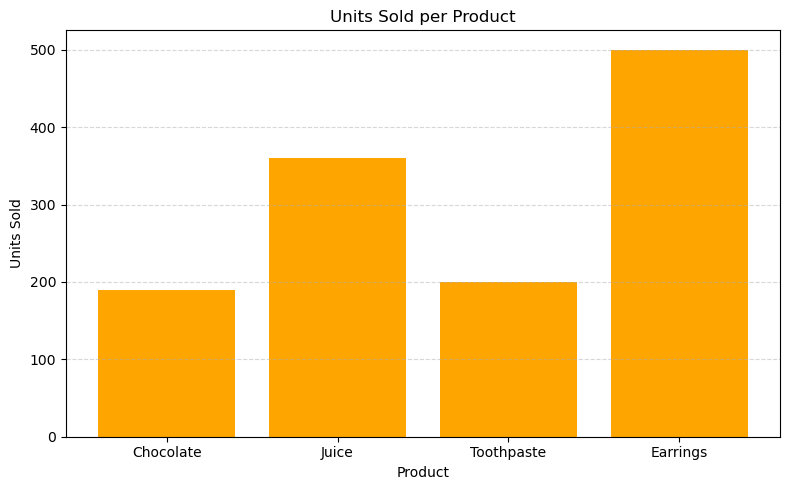

In [9]:
cursor.execute("SELECT product, unitsold FROM sale")
data = cursor.fetchall()
products = [row[0] for row in data]
units = [row[1] for row in data]
plt.figure(figsize=(8, 5))
plt.bar(products, units, color='orange')
plt.title('Units Sold per Product')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()